# Exploratory Data Analysis — AI4I 2020 Predictive Maintenance Dataset

This notebook explores the AI4I 2020 dataset before any modelling decisions are made.
The goal is to understand distributions, class imbalance, and relationships between features.

**Dataset:** 10,000 CNC machine sensor readings with binary failure labels.  
**Source:** UCI Machine Learning Repository

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')

from src.data_loader import load_raw_data

# Load the dataset
df = load_raw_data(filepath='../data/raw/ai4i2020.csv')

# Basic info
print(f"Shape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nBasic Statistics:")
df.describe()

Data loaded successfully: 10000 rows, 14 columns
Shape: (10000, 14)

Data Types:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Missing Values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                  

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Failure Distribution:
  No Failure (0): 9661 samples (96.6%)
  Failure    (1): 339 samples (3.4%)


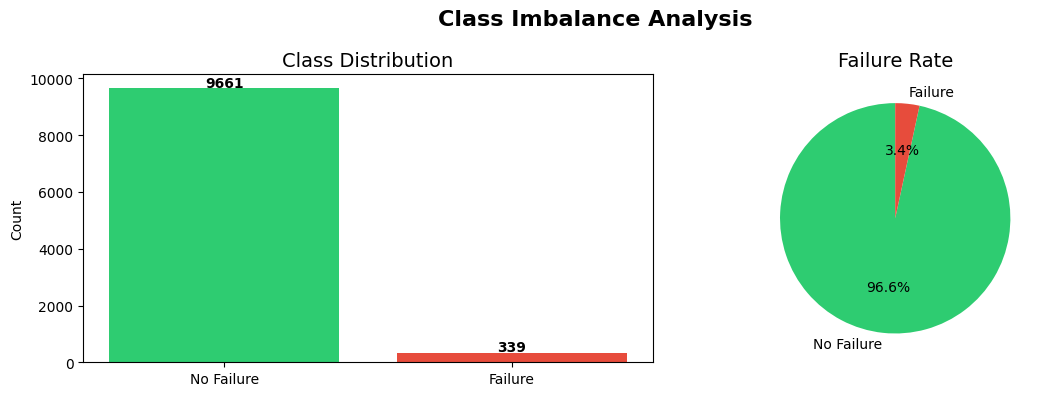

In [2]:
# Class imbalance analysis
failure_counts = df['Machine failure'].value_counts()
failure_pct = df['Machine failure'].value_counts(normalize=True) * 100

print("Failure Distribution:")
print(f"  No Failure (0): {failure_counts[0]} samples ({failure_pct[0]:.1f}%)")
print(f"  Failure    (1): {failure_counts[1]} samples ({failure_pct[1]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['No Failure', 'Failure'], failure_counts, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution', fontsize=14)
axes[0].set_ylabel('Count')
for i, v in enumerate(failure_counts):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(failure_counts, labels=['No Failure', 'Failure'], 
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Failure Rate', fontsize=14)

plt.suptitle('Class Imbalance Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

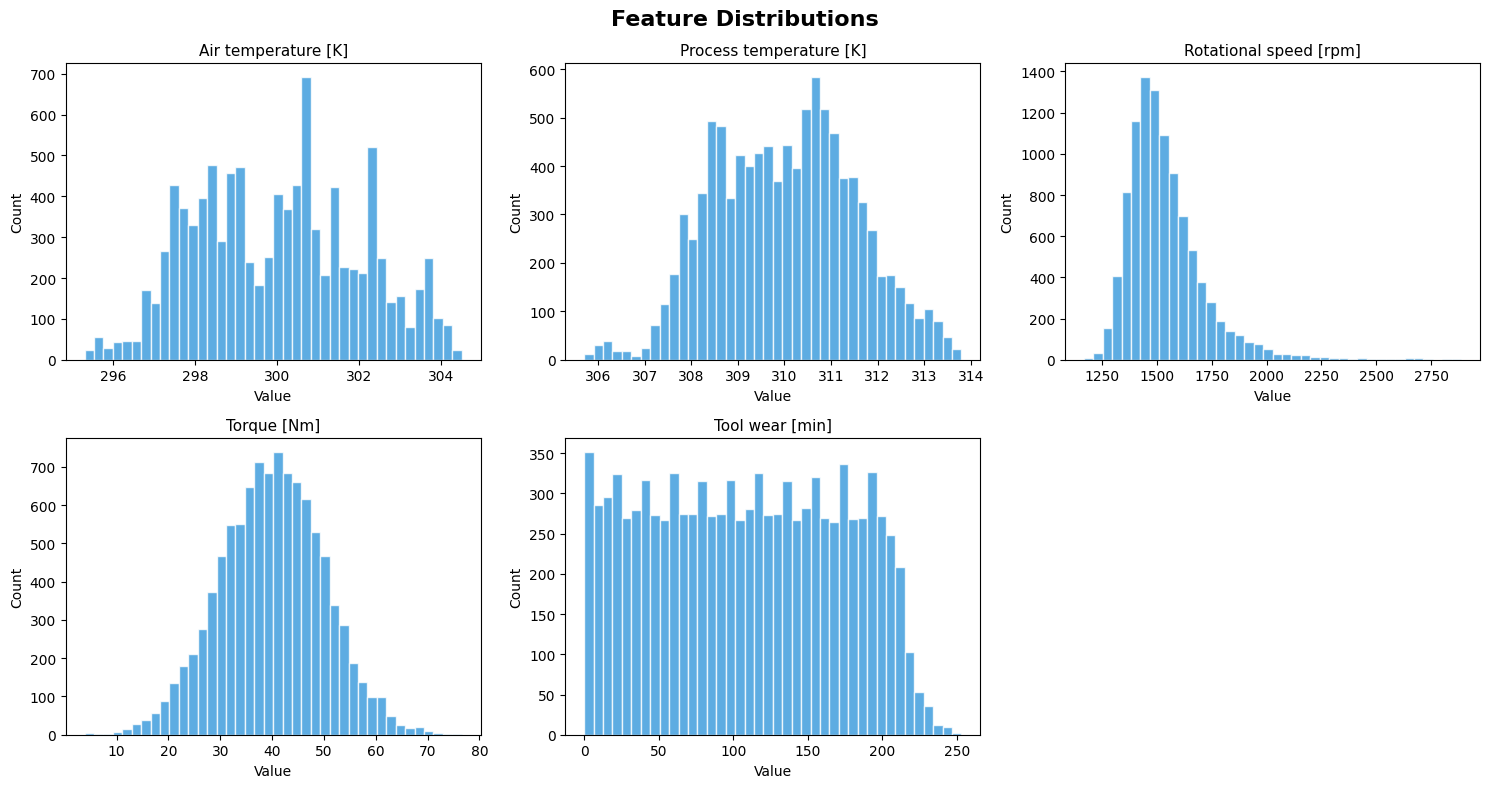

In [3]:
# Feature distributions
numerical_features = [
    'Air temperature [K]', 'Process temperature [K]',
    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    axes[i].hist(df[feature], bins=40, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{feature}', fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

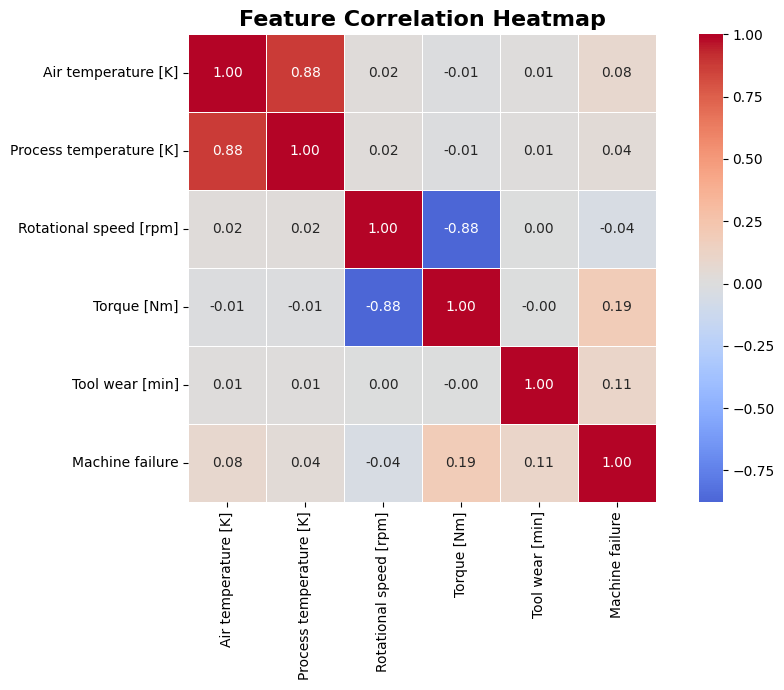

In [4]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
numerical_df = df[numerical_features + ['Machine failure']]
corr_matrix = numerical_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()